In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# from google.colab import files
# filename=files.upload()

In [5]:
import io
#filename1=next(iter(filename))
df=pd.read_csv("large_weather_prediction_dataset.csv")
df.head()

,temperature,humidity,wind_speed,pressure,visibility,cloud_cover,weather
0,23.59,35.68,15.69,1018.76,5.16,65.02,Sunny
1,26.81,43.59,14.02,1018.01,9.64,36.48,Cloudy
2,26.58,7.11,20.04,1004.03,2.20,20.91,Sunny
3,52.01,82.53,5.17,997.28,13.12,67.27,Rainy
4,18.30,47.23,10.39,1035.68,13.96,34.13,Cloudy


In [6]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['weather']=le.fit_transform(df['weather'])
df

,temperature,humidity,wind_speed,pressure,visibility,cloud_cover,weather
0,23.59,35.68,15.69,1018.76,5.16,65.02,2
1,26.81,43.59,14.02,1018.01,9.64,36.48,0
2,26.58,7.11,20.04,1004.03,2.20,20.91,2
3,52.01,82.53,5.17,997.28,13.12,67.27,1
4,18.30,47.23,10.39,1035.68,13.96,34.13,0
...,...,...,...,...,...,...,...
149995,25.81,42.47,4.34,1029.28,13.59,50.93,1
149996,25.93,68.51,17.97,1019.10,7.45,70.79,0
149997,13.15,36.06,6.31,1032.78,9.20,22.99,1
149998,21.55,81.39,10.11,1008.13,4.17,0.00,1


In [7]:
x=df.drop(['weather'], axis=1)
y=df['weather']

In [8]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest=train_test_split(x, y, test_size=0.2, random_state=0)

In [9]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
q = sc.fit_transform(xtrain)
xtrain=sc.transform(xtrain)
xtest=sc.transform(xtest)

In [10]:
from sklearn.svm import SVC
classifier=SVC(kernel='linear', random_state=0, probability=True)
classifier.fit(xtrain, ytrain)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [11]:
ypred=classifier.predict(xtest)

In [12]:
from sklearn.metrics import *
cm=confusion_matrix(ytest, ypred)
print(cm)
print("Accuracy: ", accuracy_score(ytest, ypred))
print("Precision: ", precision_score(ytest, ypred, average='weighted'))
print("Recall: ", recall_score(ytest, ypred, average='weighted'))
print("F1 Score: ", f1_score(ytest, ypred, average='weighted'))
print("AUC: ", roc_auc_score(ytest, classifier.predict_proba(xtest), multi_class='ovr', average='weighted'))

[[6265 1360 2253]
 [2112 6939 1142]
 [1409 1375 7145]]
Accuracy:  0.6783
Precision:  0.6788658485918927
Recall:  0.6783
F1 Score:  0.6782101857364068
AUC:  0.8439391039398961


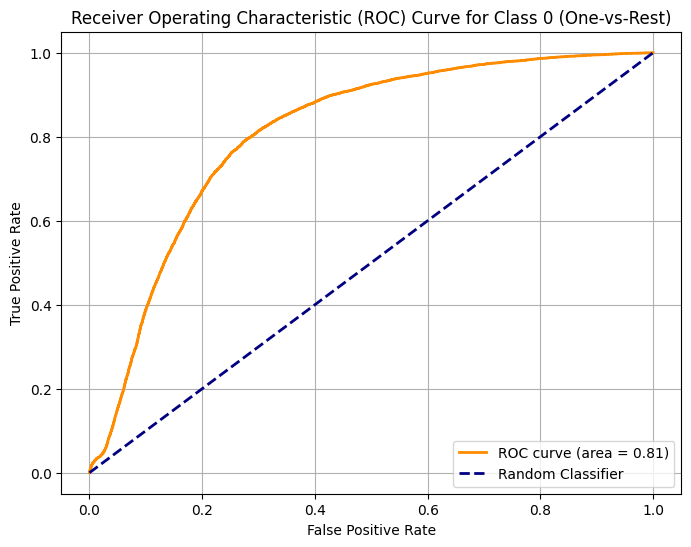

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities for each class from the logistic regression model
y_proba = classifier.predict_proba(xtest)

# Calculate ROC curve and AUC for class 0 (one-vs-rest)
# ytest == 0 creates a binary array where True means ytest is class 0, False otherwise.
fpr, tpr, _ = roc_curve(ytest == 0, y_proba[:, 0])
roc_auc = roc_auc_score(ytest == 0, y_proba[:, 0])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Class 0 (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [18]:
from sklearn.svm import SVC

classifier = SVC(
    kernel='rbf',
    random_state=0,
    probability=True
)

classifier.fit(xtrain, ytrain)

ypred = classifier.predict(xtest)

In [19]:
ypred=classifier.predict(xtest)

In [20]:
from sklearn.metrics import *
cm=confusion_matrix(ytest, ypred)
print(cm)
print("Accuracy: ", accuracy_score(ytest, ypred))
print("Precision: ", precision_score(ytest, ypred, average='weighted'))
print("Recall: ", recall_score(ytest, ypred, average='weighted'))
print("F1 Score: ", f1_score(ytest, ypred, average='weighted'))
print("AUC: ", roc_auc_score(ytest, classifier.predict_proba(xtest), multi_class='ovr', average='weighted'))

[[9228  355  295]
 [ 756 9188  249]
 [ 214  169 9546]]
Accuracy:  0.9320666666666667
Precision:  0.9325055268655468
Recall:  0.9320666666666667
F1 Score:  0.9320054865264683
AUC:  0.9865837794337164


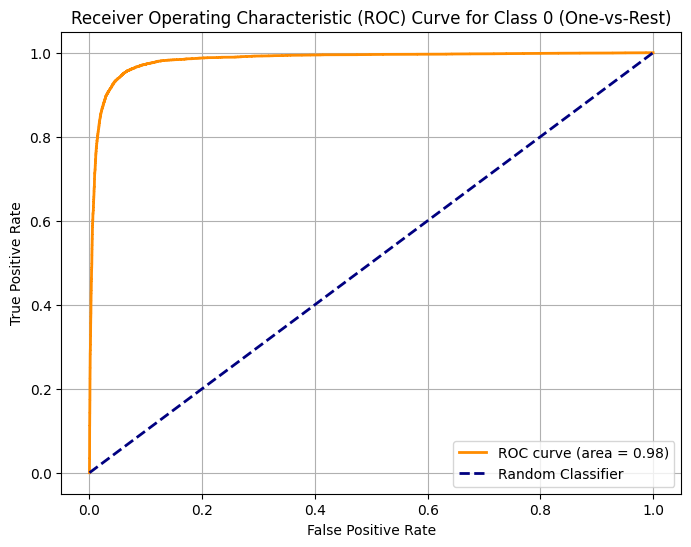

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities for each class from the logistic regression model
y_proba = classifier.predict_proba(xtest)

# Calculate ROC curve and AUC for class 0 (one-vs-rest)
# ytest == 0 creates a binary array where True means ytest is class 0, False otherwise.
fpr, tpr, _ = roc_curve(ytest == 0, y_proba[:, 0])
roc_auc = roc_auc_score(ytest == 0, y_proba[:, 0])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Class 0 (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()